<a href="https://colab.research.google.com/github/RogerReateguiUTEC/MachineLearning/blob/main/Copia_de_Regresion_Lineal_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Práctica Guiada.
 ----
  
  Universidad : La Salle \\
  Curso       : Inteligencia Artificial \\
  Profesor    : Cristian López Del Alamo \\
  Tema        : Regresión Lineal \\
  Integrantes : Gabriela Pacco Huamaní - Cesar Laura Mamaní
  

 ----



## NOTA: Saque una copia de este colab para poder trabajar en su ordenador.

1.  En esta práctica se pide realizar pruebas utilizando   diferentes funciones de pérdida.

2.  Su equipo debe implementar el algoritmo de machine learning para  regresión lineal y realizar las correspondientes pruebas el siguiente  [Dataset](https://drive.google.com/file/d/1W60C0Vkqx6qWhIZLADezokQugMwmfb22/view?usp=sharing).  

3.  Deberá seleccionar del Dataset un 70% para entrenamiento y un 30% para realizar *testing*. Recuerde que los datos tanto para entrenamieto como para *testing* deben ser tomados aleatoriamente \\

4. Utilizar las siguientes funciones de pérdida para realizar las comparaciones. Además, recuerde que las derivadas van a cambiar cada vez que cambie le función de pérdida.

  *   MSE Loss Function \\

    $MSE = \frac{1}{2m}\sum_{i=0}^m (y_i - h(x_i)) ²$ \\

  *   MAE Loss Function \\
$MAE = \frac{1}{m}\sum_{i=0}^m |y_i - h(x_i)|$ \\

Existen otras funciones de pérdida en regresión. A continuación mostramos dos de ellas.

  *   Hubber Loss Function \\
\begin{align}
L(y,h(x)) = \left\{ \begin{array}{cl}
\frac{1}{2} \left[y-h(x)\right]^2 & \text{for }|y-h(x)| \le \delta, \\
\delta \left(|y-h(x))|-\delta/2\right) & \text{otherwise.}
\end{array}\right.
\end{align} \\

  *   Log cosh Loss \\
  $LCE = \sum_{i=0}^m \log(cosh(y_i - h(x_i)))$  \\


# Gráfica comparativa entre funciones de pérdida.
Fuente: https://programmerclick.com/article/23511327338/

 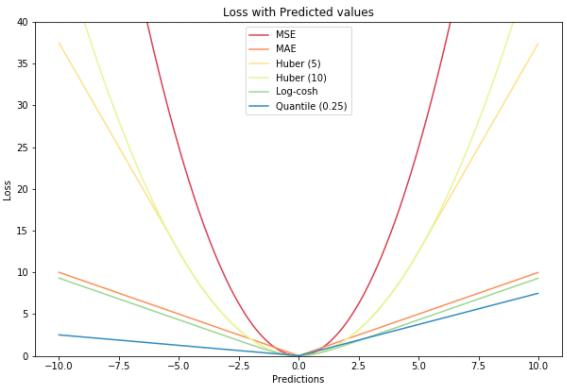

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Crear el DataSet







In [ ]:
dataset = pd.read_csv('/content/db.csv')

dataset.head()


,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [ ]:
dataset['income_norm']= (dataset['income']-dataset['income'].mean())/dataset['income'].std()
dataset['happiness_norm']= (dataset['happiness']-dataset['happiness'].mean())/dataset['happiness'].std()

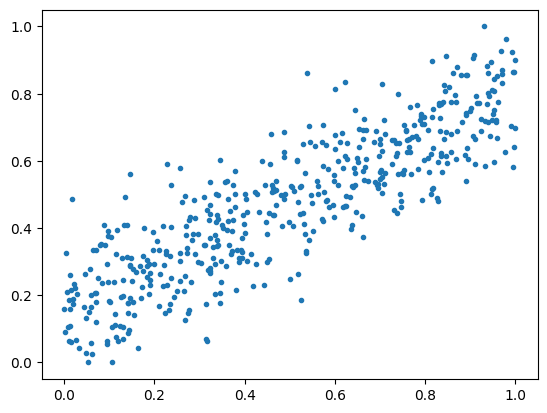

In [ ]:
x = (dataset[['income_norm']]).to_numpy()
y = (dataset[['happiness_norm']]).to_numpy()
x =(x-min(x))/(max(x)-min(x))
y =(y-min(y))/(max(y)-min(y))
plt.plot(x,y,'.')
plt.show()

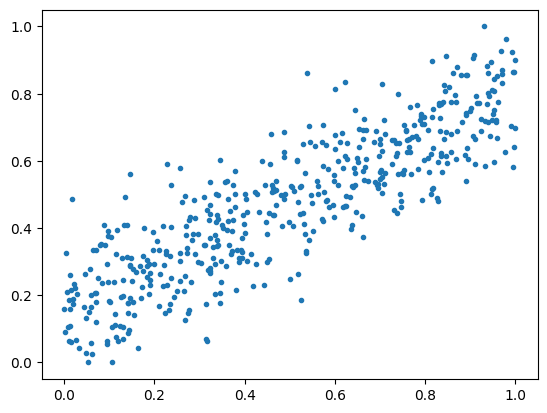

In [ ]:
x2 = (dataset[['income']]).to_numpy()
y2 = (dataset[['happiness']]).to_numpy()
x2 =(x-min(x))/(max(x)-min(x))
y2 =(y-min(y))/(max(y)-min(y))
plt.plot(x2,y2,'.')
plt.show()

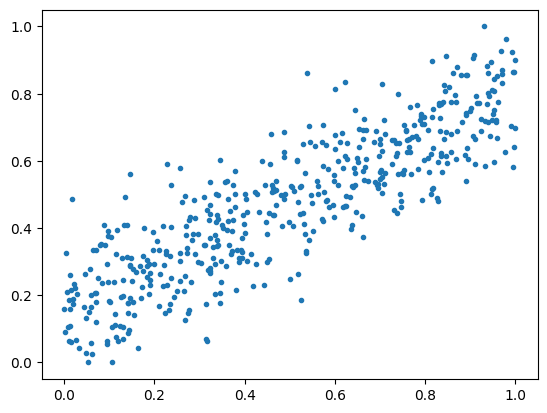

In [ ]:
x3 = (dataset[['income_norm']]).to_numpy()
y3 = (dataset[['happiness_norm']]).to_numpy()
x3 =(x-min(x))/(max(x)-min(x))
y3 =(y-min(y))/(max(y)-min(y))
plt.plot(x3,y3,'.')
plt.show()

# Modelo
$h(x_i) = x_i*w + b$

In [ ]:
def h(x, w, b):
   return np.dot(x,w) + b

# Loss function
$\mathcal{L} = \frac{1}{2n}\sum_{i=0}^n (y_i - h(x_i))^2$

In [ ]:
def Error(x, y, w, b):
  n=len(x)
  return (1/(2*n))*sum([(yi- h(xi,w,b))**2 for xi,yi in zip(x,y)])

# Cálculo de derivadas
$db = \frac{1}{m}\sum_{i=0}^m(y_i - h(x_i))(-1)$

$dw = \frac{1}{m}\sum_{i=0}^m(y_i - h(x_i))(-x_i)$

In [ ]:
def derivada(x, y, w, b):
  n=len(x)
  dw = (1/n)*sum([xi*(h(xi,w,b)-yi) for xi,yi in zip(x,y)])
  db = (1/n)*sum([h(xi,w,b)-yi for xi,yi in zip(x,y)])
  return  db, dw
#def predict(x,w,b):
#  return h(x,w,b)


# Actualiación de parámetros

$h(x_i) = b + x_i*w $

$w  = w - \alpha*\frac{\partial L}{\partial w} $

$b  = b - \alpha*\frac{\partial L}{\partial b} $


In [ ]:
def update(w, b, alfa, db, dw):
  w = w - alfa*dw
  b = b - alfa*db
  return b, w



# Training

In [ ]:
def train(x, y, epochs, alfa):
    np.random.seed(2001)
    w = np.random.rand()
    b = np.random.rand()
    L = Error(x, y, w, b)
    loss = []
    for i in range(epochs):
        db, dw = derivada(x, y, w, b)
        b, w = update(w, b, alfa, db, dw)
        L = Error(x, y, w, b)
        if(i%20==0):
          loss.append(L)

          plt.plot(x,h(x,w,b))

          print(L)
    return b, w,loss

def Plot_Loss(epochs,loss):
   plt.plot(range(epochs), loss)

# Testing

In [ ]:
def test(x,y,w,b):
  return h(x ,w, b)


[0.06236136]
[0.04173976]
[0.02928771]
[0.02175036]
[0.01717012]


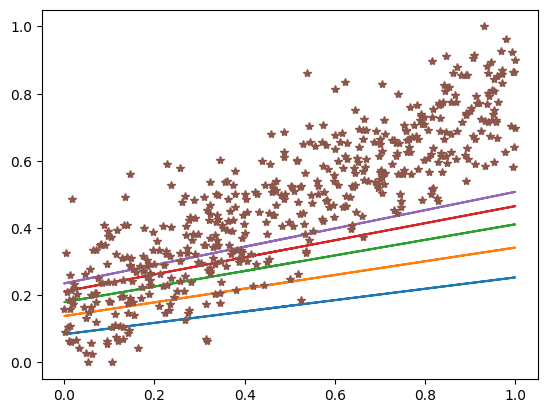

In [ ]:
b, w,loss = train(x, y, 100, 0.01)
plt.plot(x,y,'*')
#plt.plot(range(len(loss)),loss)
plt.show()

[0.06236136]
[0.04173976]
[0.02928771]
[0.02175036]
[0.01717012]


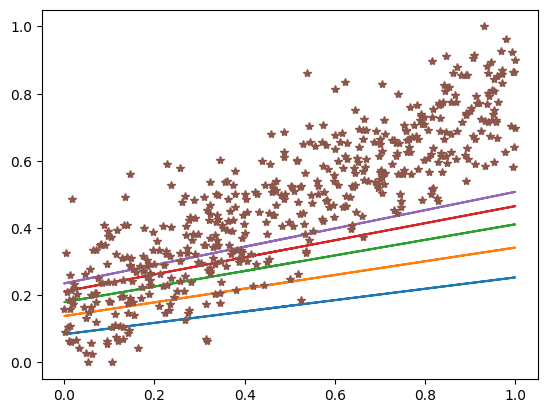

In [ ]:
b2, w2,loss2 = train(x2, y2, 100, 0.01)
plt.plot(x2,y2,'*')
#plt.plot(range(len(loss)),loss)
plt.show()

[0.06236136]
[0.04173976]
[0.02928771]
[0.02175036]
[0.01717012]


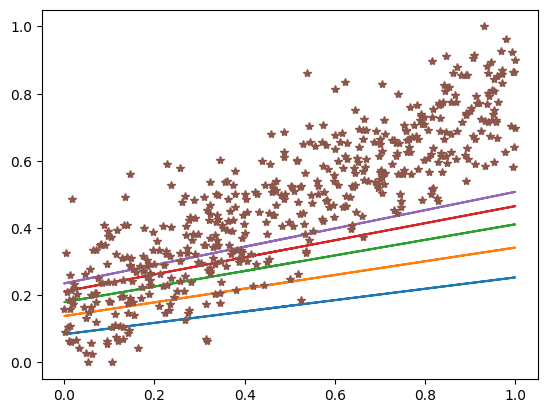

In [ ]:
b3, w3,loss3 = train(x3, y3, 100, 0.01)
plt.plot(x3,y3,'*')
#plt.plot(range(len(loss)),loss)
plt.show()

# Luego de ejecutar la práctica en equis
1. Si su modelo corrió, puede notar que el valor del error está subiendo y bajando ? Si es así, cual cree que es la causa?

- Los puntos sin normalizar, es decir no estan estandadarizados en una escala común, por lo que los puntos estan dispersos, por ello la gradiente tiene mucha varibilidad ya que hay puntos pequeños y grandes.




2. Ahora, tranforme los valores de X y Y a valores entre [0,1], es decir
normalize los datos  usando esta ecuación v = (v-min)/(max-min) donde v, puede ser x, o y dependiendo que variabe está normalizando. Luego ejecute nuevamente su código.

7. Entrene su modelos con distintos valores del \alpha  $\{0.5,0.1,0.01,0.001,0.00001\}$ y luego de entrenar el modelo verique el error promedio de los testing correspondientes.


[0.01778997]
[0.00711558]
[0.00621231]
[0.00598026]
[0.00592064]


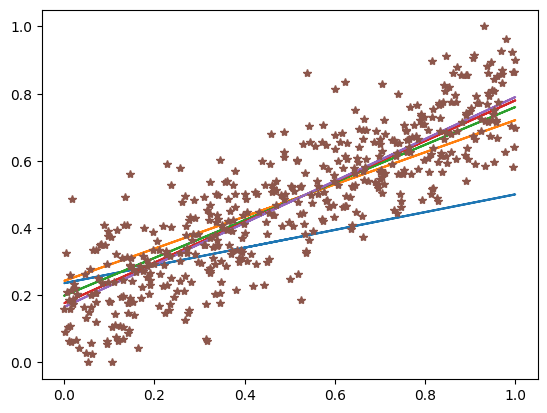

In [ ]:
b, w,loss = train(x, y, 100, 0.5)
plt.plot(x,y,'*')


[0.05114565]
[0.00990313]
[0.00882354]
[0.00813531]
[0.00760957]


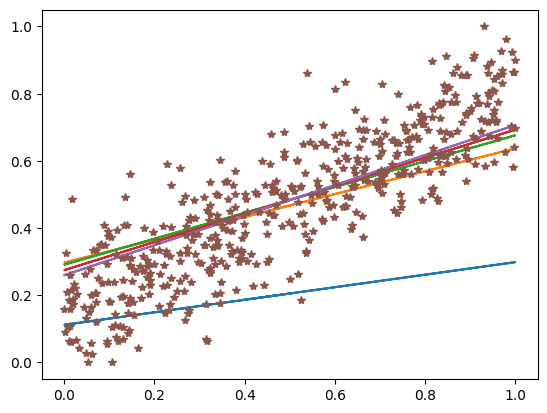

In [ ]:
b, w,loss = train(x, y, 100, 0.1)
plt.plot(x,y,'*')


[0.06236136]
[0.04173976]
[0.02928771]
[0.02175036]
[0.01717012]


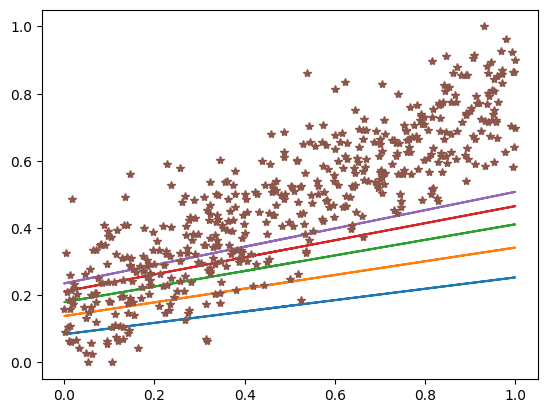

In [ ]:
b, w,loss = train(x, y, 100, 0.01)
plt.plot(x,y,'*')


[0.0635579]
[0.06095157]
[0.05847309]
[0.05611617]
[0.05387481]


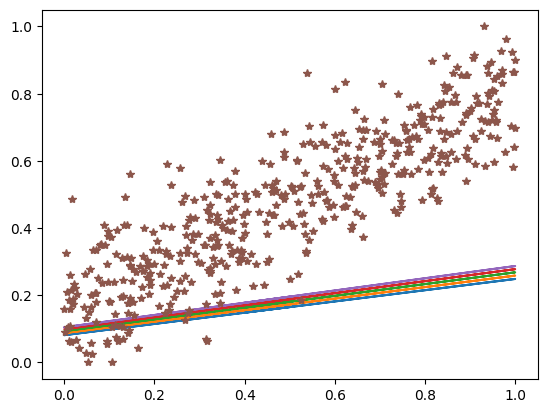

In [ ]:
b, w,loss = train(x, y, 100, 0.001)
plt.plot(x,y,'*')


[0.06369156]
[0.06368888]
[0.0636862]
[0.06368353]
[0.06368085]


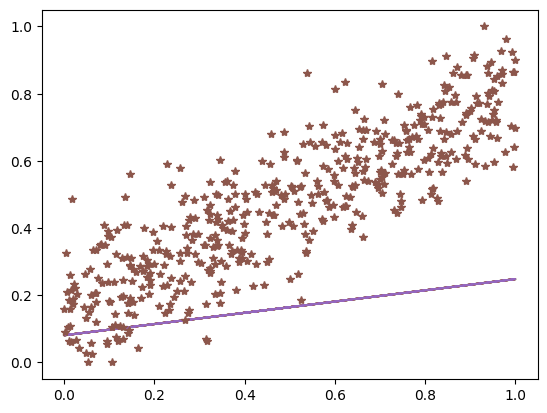

In [ ]:
b, w,loss = train(x, y, 100, 0.000001)
plt.plot(x,y,'*')


8. ¿Qué ocurre cuando el valor de \alpha está cerca a 1 y que si es muy pequeño?

- Cuando el valor de alpha esta cerca a 1 el tiende a cero, con el valor alpha 0.999 nos da un error de [0.00590005]
- Cuando el valor de alpha es muy pequeño el error es muy grande,con el valor alpha 0.000001 nos da un error de [0.06367951]

[0.0139251]
[0.00617835]
[0.0059176]
[0.00590114]
[0.0059001]


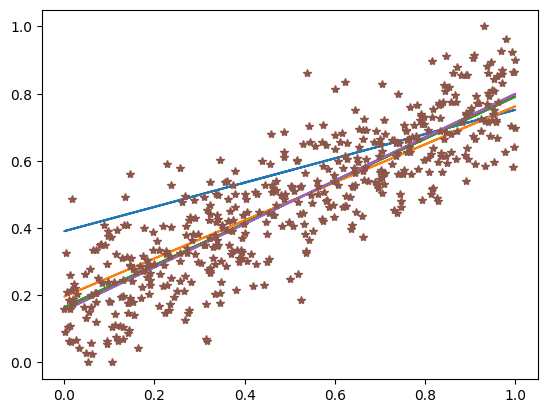

In [ ]:
b, w,loss = train(x, y, 100, 0.999)
plt.plot(x,y,'*')


[0.06369156]
[0.06368888]
[0.0636862]
[0.06368353]
[0.06368085]


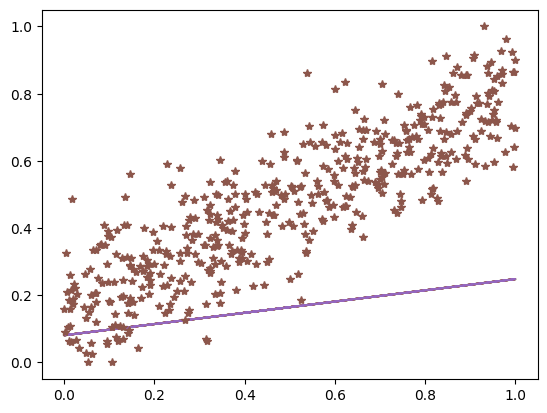

In [ ]:
b, w,loss = train(x, y, 100, 0.000001)
plt.plot(x,y,'*')